# C2 — v1 vs. v2: the same architectures, before and after the fixing rounds

Every architecture that has a checkpoint in **both** generations is loaded twice — once from `models/v1/` (the pre-`fixing.md` run) and once from `models/deterministic/` / `models/nll/` (the current run) — and the two are scored side by side on the **same `data/test/` images**, with the same signals, tables and figures the 04x/05x series uses.

**What actually changed between the two generations** (`fixing.md`, Rounds 1-2), i.e. what this notebook is measuring the effect of:

| | `v1` | `v2` (`deterministic/` + `nll/`) |
|---|---|---|
| normalization | `BatchNormalization` | `GroupNormalization` (`scripts/norm_utils.py`) |
| ReLU | `layers.ReLU()` | `_ReLUFix` (tensorflow-metal NaN workaround) |
| deterministic loss | per-architecture (`combined_loss` / `combined_loss_advanced`) | unified `combined_loss` (Charbonnier + 1-MS-SSIM) |
| NLL loss | `gaussian_nll` (`models/v1/<arch>_nll/`), `beta_nll` (`models/v1/nll_beta/`) | unified `laplace_nll` |
| 2nd NLL channel | Gaussian **log-variance** → `sigma = exp(0.5 * ch1)` | Laplace **log-scale** → `sigma = sqrt(2) * exp(ch1)` |
| optimizer | plain Adam | Adam + `weight_decay` + `clipvalue` |
| EfficientNet | frozen encoder only | + a two-phase `_ft` fine-tuning checkpoint (v2-only, no v1 pair) |

**Read the tables with these two caveats in mind.**

1. The NLL second channel means *different things* in the two generations (row 5 above), so §3 converts it per generation rather than applying one formula to both — the exact mistake `fixing.md` #10 documents. Everything derived from `sigma` (`\|z\|`, structural z, calibration) depends on that conversion being right.
2. `nll` in §8 is a **negative log-likelihood under a different distribution** on each side (Gaussian nats vs. Laplace nats) and is therefore *not* comparable across the two columns. Coverage, `z_std`, Spearman(error, sigma), sharpness and dispersion treat `sigma` as a plain standard deviation and *are* comparable.

Companion notebooks: `040`/`041` (signals vs. ground-truth masks, current generation only), `052` (a user-chosen subset of current models against each other). This one is the only place the two generations meet.

Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check. Same building blocks as the 04x/05x series: `scripts.delta_analysis` for the delta/structural maps, `scripts.calibration` for the z-score signals and the sigma metrics, `scripts.detection` for AUROC against the hand-drawn masks, `scripts.stroke_stats` for the reference-free corroboration.

In [2]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import (
    evaluate_calibration,
    laplace_sigma_from_scale,
    learned_zscore,
    structural_zscore,
)
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.detection import evaluate_detection
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import DEFAULT_Z_SCALE, plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. The `data/test/` images

Every `(rgb, ir)` pair under `data/test/`, discovered generically. The three with a hand-drawn mask in `data/test/annotations/*_Map.png` (`GT01`, `GT02`, `GT03`) additionally carry a detection ground truth — §6's AUROC is restricted to those, everything else (fidelity, coherence, calibration) needs no mask and runs on all of them.

In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) + sorted(TEST_RGB_DIR.glob("*.png"))
image_pairs = [
    (p, TEST_IR_DIR / p.name)
    for p in sorted(rgb_paths)
    if (TEST_IR_DIR / p.name).exists()
]
gt_stems = {
    p.name.removesuffix("_Map.png") for p in sorted(ANNOTATIONS_DIR.glob("*_Map.png"))
}
gt_stems &= {p.stem for p, _ in image_pairs}

print(f"data/test/ images: {len(image_pairs)} | {[p.stem for p, _ in image_pairs]}")
print(f"with a ground-truth mask: {sorted(gt_stems)}")

if not image_pairs:
    raise RuntimeError("No (rgb, ir) pairs found under data/test/.")

data/test/ images: 10 | ['GT01', 'GT02', 'GT03', 'bridge', 'case', 'face', 'green', 'modern', 'modern2', 'total']
with a ground-truth mask: ['GT01', 'GT02', 'GT03']


## 2. The two generations, and which architectures they share

`VERSIONS` says where each generation's checkpoints live and how to read its NLL second channel — the only two things that differ structurally between them. `v1` keeps deterministic and NLL checkpoints in one flat `models/v1/` directory; `v2` splits them into `models/deterministic/` and `models/nll/`.

`ARCH_PAIRS` lists only architectures present in **both** generations, since a one-sided entry has nothing to compare against: `unet_v2`/`unet_restormer` are v1-only, `efficientnet_unet_ft`/`efficientnet_unet_nll_ft` and `unet_dilated`/`unet_v2_dilated` are v2-only. Any architecture missing a checkpoint on either side is skipped with a message rather than raising.

**On the v1 NLL entries**: `models/v1/<arch>_nll/` holds the pre-Round-2 `gaussian_nll` checkpoints; the `beta_nll` siblings live under `models/v1/nll_beta/<arch>_nll/`. To compare against those instead, point `VERSIONS["v1"]["dir"]["nll"]` at `settings.MODELS_DIR / "v1" / "nll_beta"` and set `nll_loss` to `"beta_nll"` — the second channel is still a Gaussian log-variance, so `sigma_source` stays `"gaussian"`.

In [4]:
VERSIONS = {
    "v1": {
        "dir": {
            "deterministic": settings.MODELS_DIR / "v1",
            "nll": settings.MODELS_DIR / "v1",
        },
        # Pre-Round-2: the NLL head was trained as a Gaussian, so channel 1
        # is a log-variance and the NLL metric in §8 is in Gaussian nats.
        "nll_loss": "gaussian_nll",
        "sigma_source": "gaussian",
    },
    "v2": {
        "dir": {
            "deterministic": settings.MODELS_DIR / "deterministic",
            "nll": settings.MODELS_DIR / "nll",
        },
        # fixing.md #10: every NLL architecture is now a Laplace, so
        # channel 1 is a log-scale and sigma = b * sqrt(2).
        "nll_loss": "laplace_nll",
        "sigma_source": "laplace",
    },
}

ARCH_PAIRS = [
    ("unet_restormer", "deterministic"),
    ("unet_v2", "deterministic"),
]


def load_version(arch: str, family: str, version: str) -> tf.keras.Model:
    """Load one architecture's checkpoint from one generation."""
    spec = VERSIONS[version]
    model_dir = spec["dir"][family]
    if family == "deterministic":
        return load_model(arch, model_dir=model_dir)
    return load_model_nll(
        arch, model_dir=model_dir, loss_name=spec["nll_loss"], beta=settings.NLL_BETA
    )


missing = [
    (arch, version)
    for arch, family in ARCH_PAIRS
    for version in VERSIONS
    if not (VERSIONS[version]["dir"][family] / arch / "best_model.keras").exists()
]
print(f"Architecture pairs to compare: {[a for a, _ in ARCH_PAIRS]}")
print(f"Missing checkpoints (will be skipped): {missing or 'none'}")

Architecture pairs to compare: ['unet_restormer', 'unet_v2']
Missing checkpoints (will be skipped): none


## 3. Signals, per generation

Identical construction to `040`/`041`/`052` — **raw delta** `|real_IR - mu|`, **structural delta** `1 - local SSIM structure`, **confidence** (their normalized agreement) for every model; plus **`\|z\|`** and **structural z** for the NLL architectures, which need a `sigma`.

The one thing that is *not* identical across the two generations is that `sigma`. `sigma_from_channel` dispatches on `VERSIONS[version]["sigma_source"]`: `exp(0.5 * ch1)` for v1's Gaussian log-variance, `laplace_sigma_from_scale(exp(ch1))` (i.e. `sqrt(2) * b`) for v2's Laplace log-scale. Applying either formula to both generations would make the z-signals and every calibration number below silently wrong — this is `fixing.md` #10's mistake, and the reason this dispatch exists rather than one shared line.

In [5]:
MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges

SIGNAL_KINDS = ("raw delta", "structural delta", "confidence")
NLL_SIGNAL_KINDS = ("|z| (raw/sigma)", "structural z")


def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def load_mask(stem: str) -> np.ndarray:
    """Load a hand-drawn ground-truth mask as a boolean array."""
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def sigma_from_channel(log_channel: np.ndarray, sigma_source: str) -> np.ndarray:
    """Turn an NLL head's second channel into a standard deviation."""
    if sigma_source == "gaussian":
        return np.exp(0.5 * log_channel)
    if sigma_source == "laplace":
        return laplace_sigma_from_scale(np.exp(log_channel))
    raise ValueError(f"Unknown sigma_source '{sigma_source}'.")


def fidelity(ir: np.ndarray, mu: np.ndarray) -> dict[str, float]:
    """MAE/SSIM/PSNR of a prediction against the real IR, as in 030."""
    real = tf.constant(ir[..., np.newaxis])
    pred = tf.constant(mu[..., np.newaxis])
    return {
        "mae": float(np.mean(np.abs(ir - mu))),
        "ssim": float(tf.image.ssim(real, pred, max_val=1.0)),
        "psnr": float(tf.image.psnr(real, pred, max_val=1.0)),
    }


def predict_signals(
    model: tf.keras.Model, family: str, version: str, rgb: np.ndarray, ir: np.ndarray
) -> tuple[dict[str, float], dict[str, np.ndarray], np.ndarray | None, np.ndarray]:
    """Predict one image and build every signal available to this family."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    pred = model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, :]

    mu = pred[..., 0]
    result = analyze_delta(ir, mu)
    signals = {
        "raw delta": result.raw_delta,
        "structural delta": result.structural_delta,
        "confidence": result.confidence_map,
    }

    sigma = None
    if family == "nll":
        sigma = sigma_from_channel(pred[..., 1], VERSIONS[version]["sigma_source"])
        signals["|z| (raw/sigma)"] = np.abs(learned_zscore(ir, mu, sigma))
        signals["structural z"] = structural_zscore(result.structural_delta, sigma)

    return fidelity(ir, mu), signals, sigma, mu

## 4. The sweep

One architecture at a time, both generations held in memory together (so their signals are built from the exact same image arrays), every `data/test/` image scored, then both released before moving to the next architecture — v1 checkpoints are ~380 MB each, so loading all sixteen at once would not fit.

`PLOT_IMAGES` and `PLOT_SIGNALS` control only the *figures*; the numeric tables in §5-§8 always cover every image and every signal. The defaults plot the three ground-truth images, where a visible difference can be checked against the mask — widen to `{p.stem for p, _ in image_pairs}` for the full qualitative sweep.

This is the long cell: `len(ARCH_PAIRS) x len(image_pairs) x 2` full-image predictions on images up to ~10 Mpx, plus the Gaussian-windowed SSIM decomposition for each.

2026-08-27 07:54:51.028077: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-27 07:54:51.028124: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-27 07:54:51.028131: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-27 07:54:51.028176: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 07:54:51.028189: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



=== unet_restormer (deterministic) — v1 vs. v2 ===


2026-08-27 07:54:53.693845: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


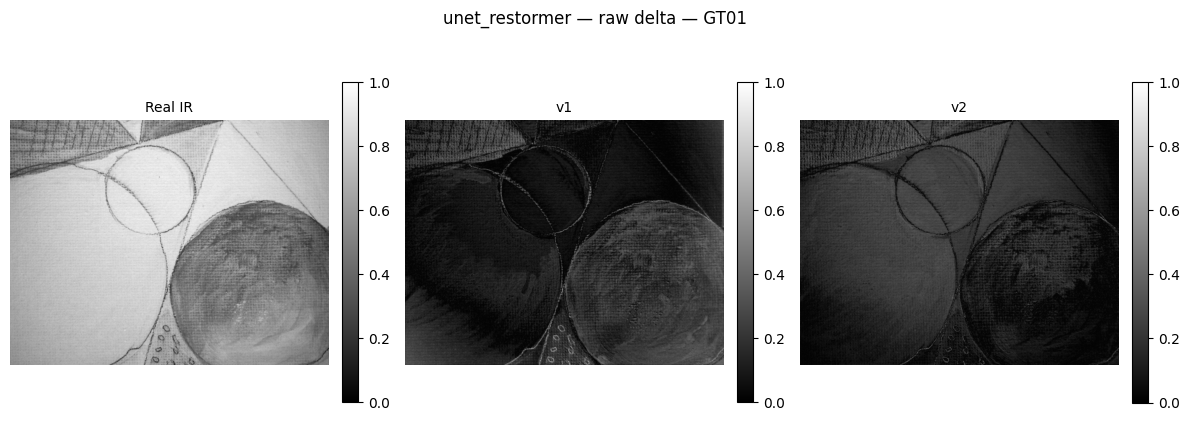

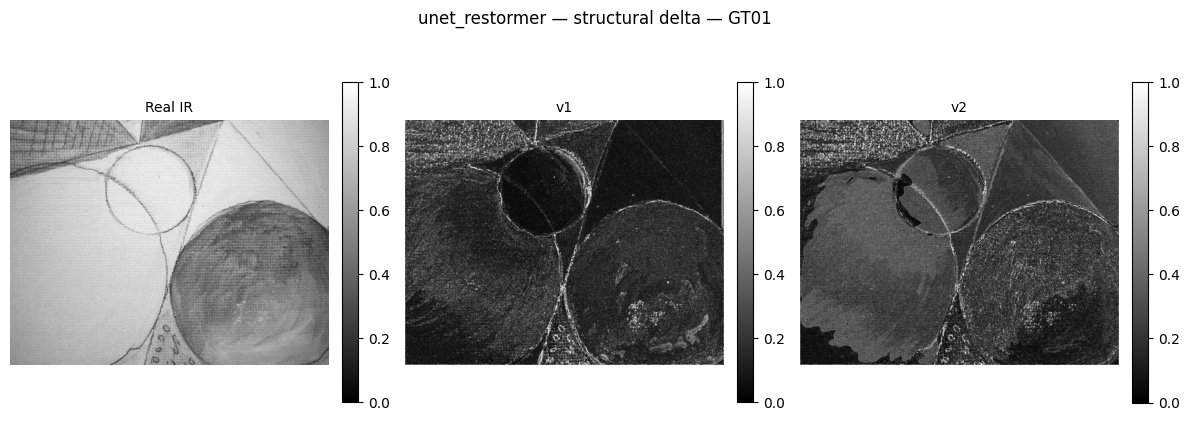

  GT01: scored


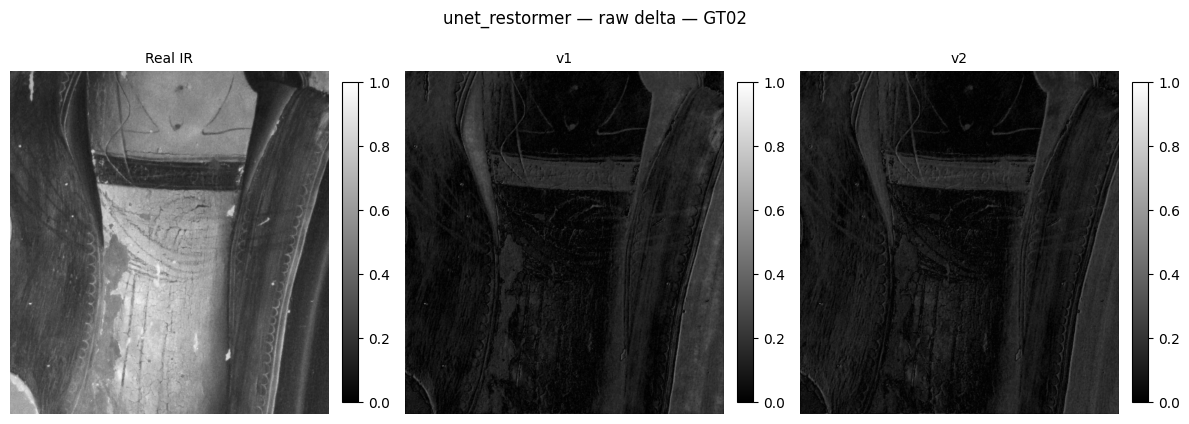

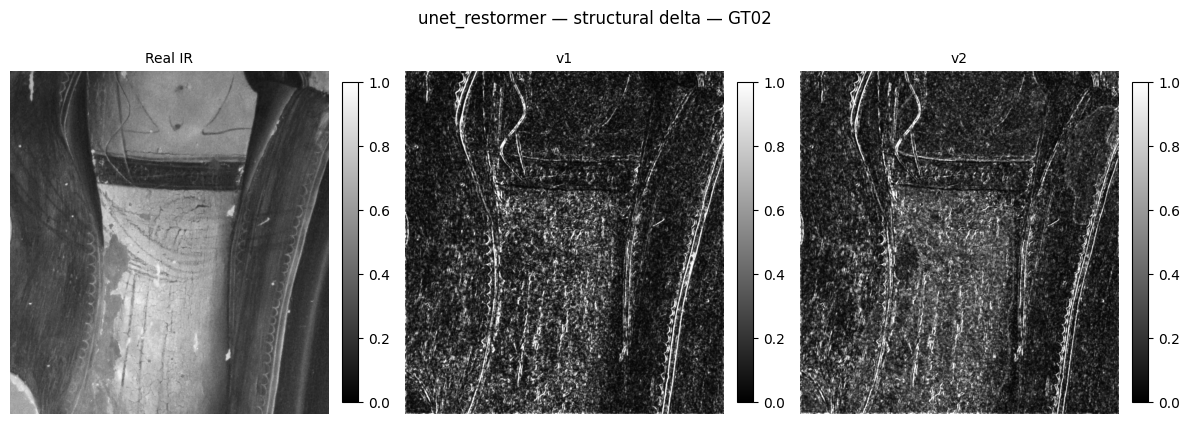

  GT02: scored


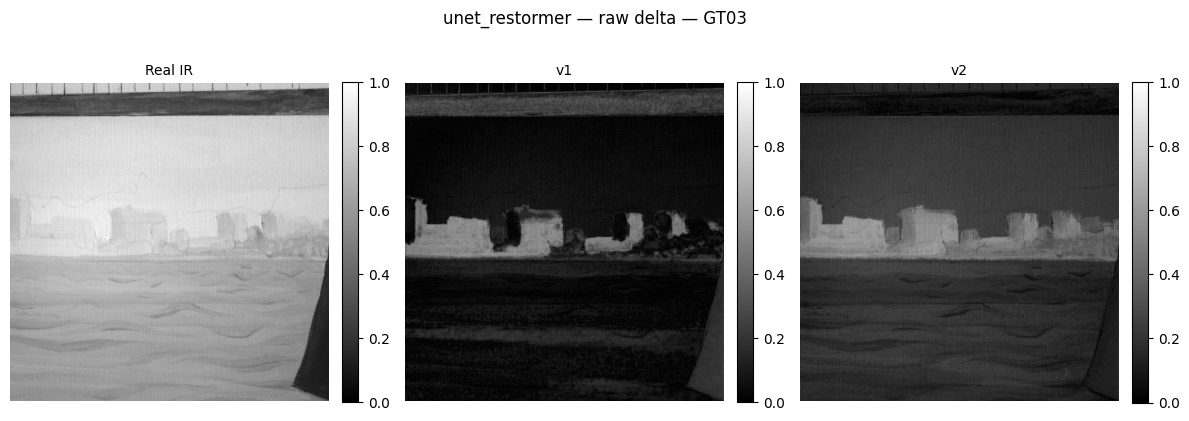

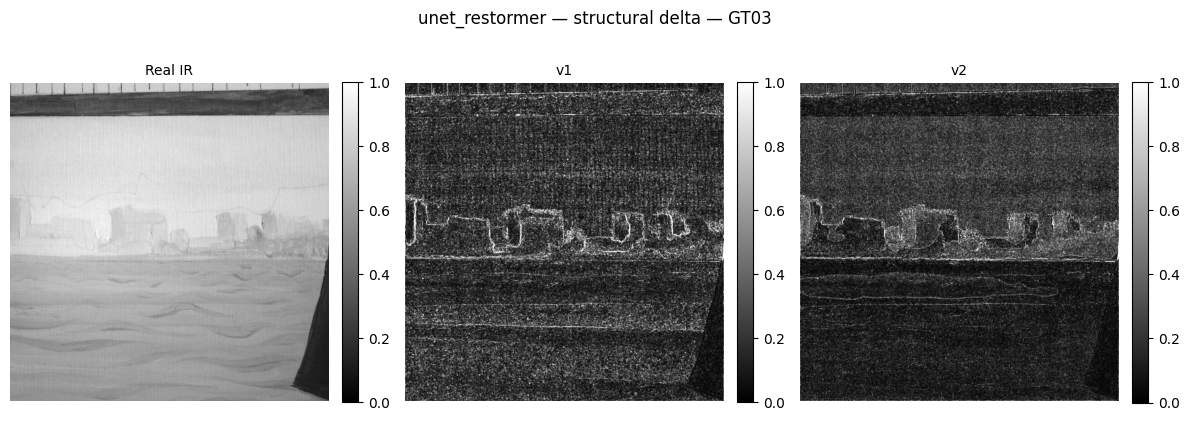

  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

=== unet_v2 (deterministic) — v1 vs. v2 ===


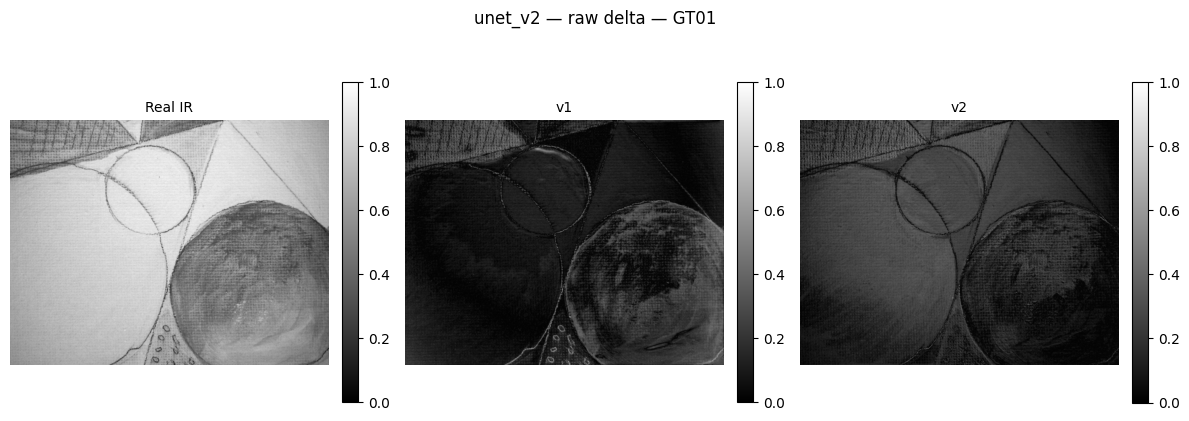

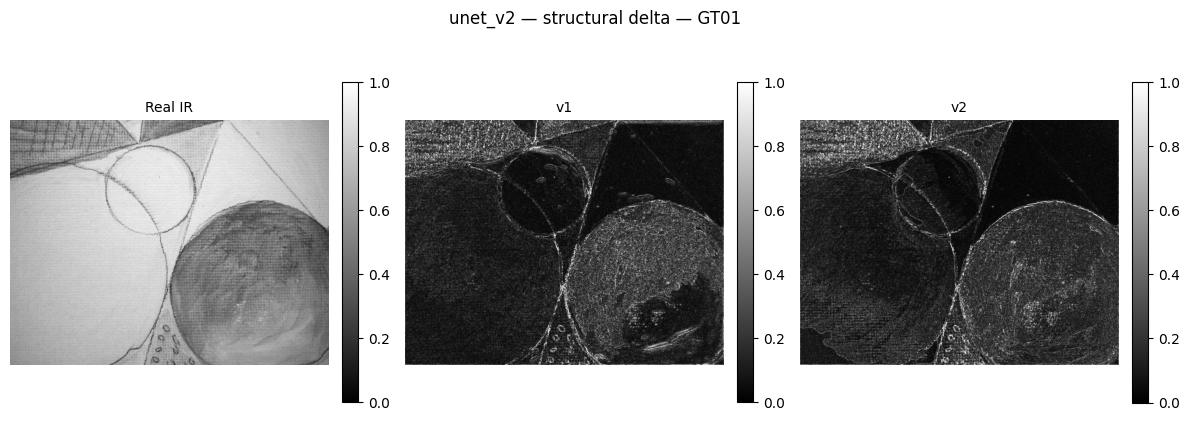

  GT01: scored


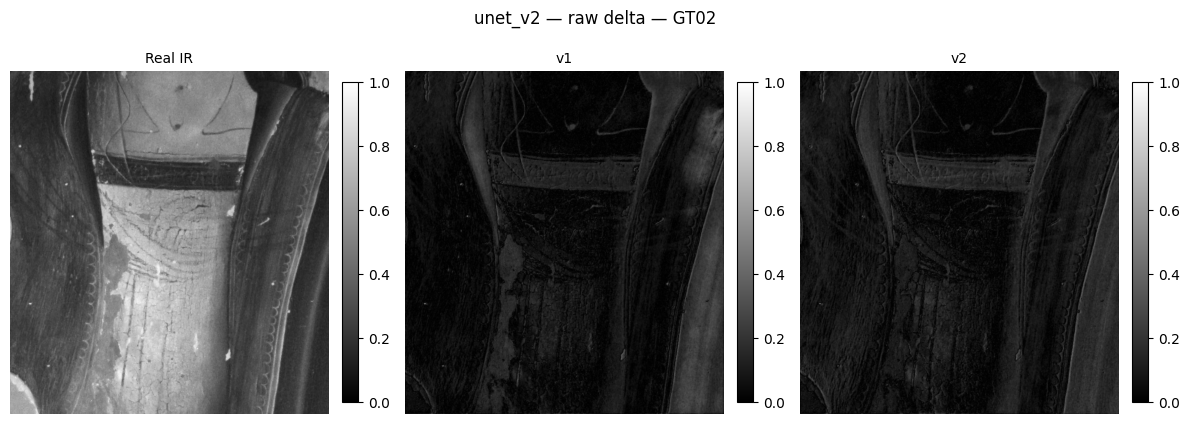

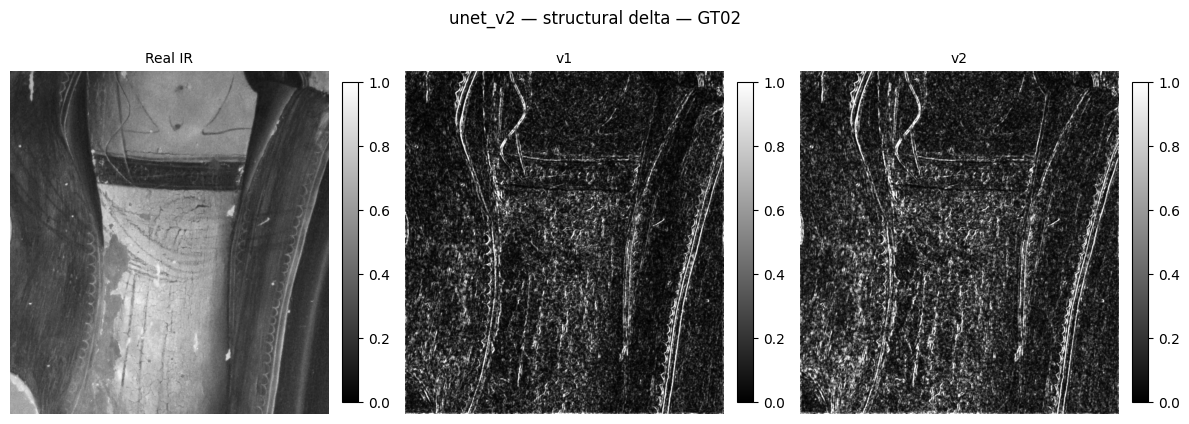

  GT02: scored


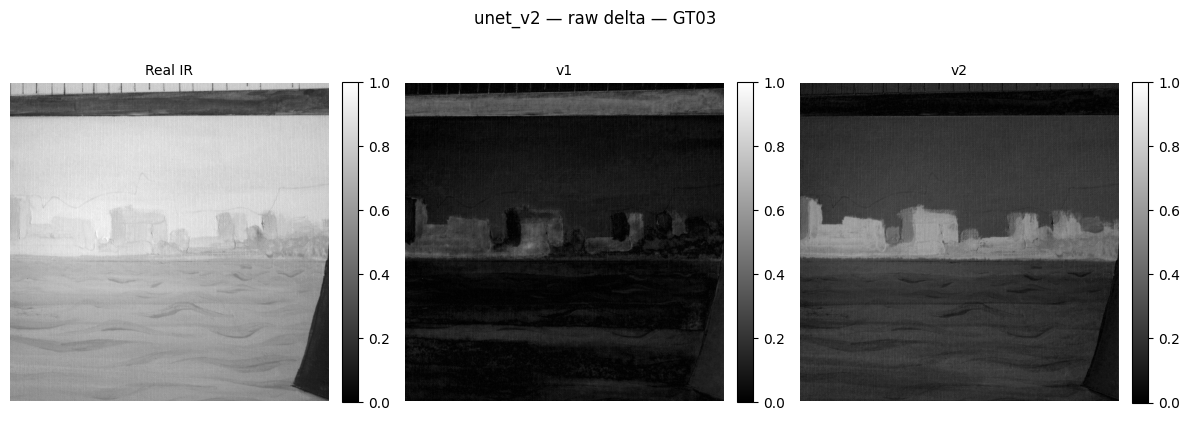

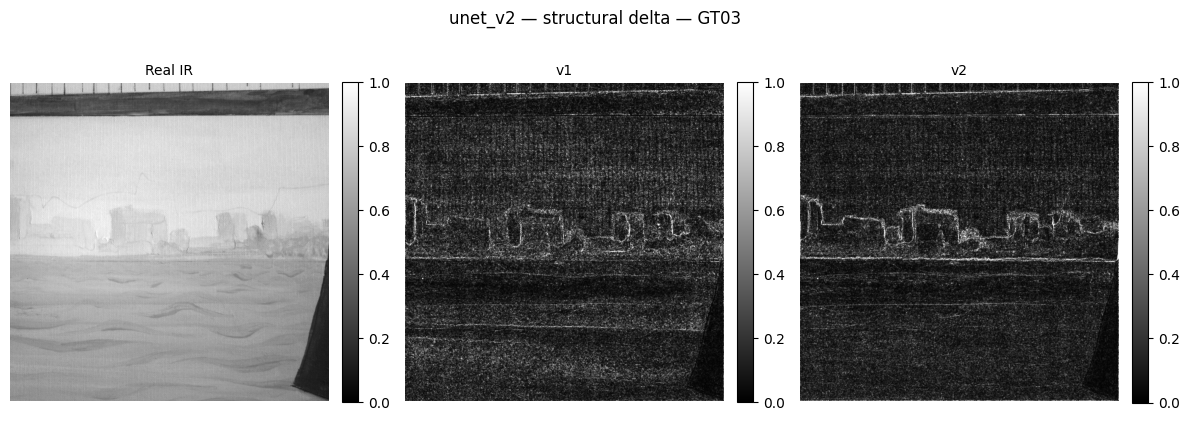

  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

Compared: ['unet_restormer', 'unet_v2']


In [6]:
PLOT_IMAGES = set(gt_stems)  # -> {p.stem for p, _ in image_pairs} for all of them
PLOT_SIGNALS = ("raw delta", "structural delta")

fidelity_rows: dict[tuple[str, str], dict[str, list[float]]] = {}
coherence_rows: dict[tuple[str, str, str], list[float]] = {}
auroc_rows: dict[tuple[str, str, str], dict[str, float]] = {}
ap_rows: dict[tuple[str, str, str], dict[str, float]] = {}
calibration_rows: dict[tuple[str, str], dict[str, list[float]]] = {}

compared_archs: list[tuple[str, str]] = []

for arch, family in ARCH_PAIRS:
    loaded: dict[str, tf.keras.Model] = {}
    for version in VERSIONS:
        try:
            loaded[version] = load_version(arch, family, version)
        except FileNotFoundError as exc:
            print(f"[skip] {arch} @ {version}: {exc}")

    if len(loaded) < len(VERSIONS):
        print(f"[skip] {arch}: needs a checkpoint in every generation to compare")
        del loaded
        gc.collect()
        tf.keras.backend.clear_session()
        continue

    compared_archs.append((arch, family))
    print(f"\n=== {arch} ({family}) — {' vs. '.join(loaded)} ===")

    for rgb_path, ir_path in image_pairs:
        stem = rgb_path.stem
        rgb, ir = load_pair(rgb_path, ir_path)
        mask = load_mask(stem) if stem in gt_stems else None

        per_version = {}
        for version, model in loaded.items():
            scores, signals, sigma, mu = predict_signals(
                model, family, version, rgb, ir
            )
            per_version[version] = signals

            for metric, value in scores.items():
                fidelity_rows.setdefault((arch, version), {}).setdefault(
                    metric, []
                ).append(value)

            for kind, signal in signals.items():
                coherence_rows.setdefault((arch, version, kind), []).append(
                    stroke_coherence(signal).coherence
                )
                if mask is not None:
                    detection = evaluate_detection(signal, mask)
                    auroc_rows.setdefault((arch, version, kind), {})[stem] = (
                        detection.auroc
                    )
                    ap_rows.setdefault((arch, version, kind), {})[stem] = (
                        detection.average_precision
                    )

            if sigma is not None:
                distribution = VERSIONS[version]["sigma_source"]
                summary = evaluate_calibration(
                    ir, mu, sigma, distribution=distribution
                ).summary()
                for metric, value in summary.items():
                    calibration_rows.setdefault((arch, version), {}).setdefault(
                        metric, []
                    ).append(value)

        if stem in PLOT_IMAGES:
            for kind in PLOT_SIGNALS:
                fig = plot_signal_comparison(
                    ir,
                    {v: s[kind] for v, s in per_version.items()},
                    title=f"{arch} — {kind} — {stem}",
                    vrange=(0.0, 1.0),
                )
                plt.show()
                plt.close(fig)
            if family == "nll":
                for kind in NLL_SIGNAL_KINDS:
                    scaled, vrange = DEFAULT_Z_SCALE.apply_many(
                        {v: s[kind] for v, s in per_version.items()}
                    )
                    fig = plot_signal_comparison(
                        ir, scaled, title=f"{arch} — {kind} — {stem}", vrange=vrange
                    )
                    plt.show()
                    plt.close(fig)

        print(f"  {stem}: scored")
        del per_version, rgb, ir, mask

    del loaded
    gc.collect()
    tf.keras.backend.clear_session()

print(f"\nCompared: {[a for a, _ in compared_archs]}")
if not compared_archs:
    raise RuntimeError(
        "No architecture had a checkpoint in both generations — nothing to compare."
    )

## 5. Reconstruction fidelity — how well each generation predicts the IR

`mae`/`ssim`/`psnr` of `mu` against the real IR, averaged over all `data/test/` images. This is the same axis `030_evaluation.ipynb` reports, and it measures the *forward* task only: a model can improve here and still surface the underdrawing worse, which is what §6 and §7 are for.

`gain` is always oriented so that **positive means v2 improved**: `v2 - v1` for `ssim`/`psnr`, `v1 - v2` for `mae` (where lower is better). Read a negative `gain` as a regression, whatever the metric.

In [7]:
# True where a *lower* value is the better one, so `gain` below can be
# oriented consistently: positive always means v2 improved.
LOWER_IS_BETTER = {"mae": True, "ssim": False, "psnr": False}


def mean_of(rows: dict, key, metric: str) -> float:
    return float(np.mean(rows[key][metric]))


def gain(metric: str, v1: float, v2: float) -> float:
    return v1 - v2 if LOWER_IS_BETTER[metric] else v2 - v1


col_w = 26
header = "architecture".ljust(col_w)
for metric in LOWER_IS_BETTER:
    header += (
        f"{metric} v1".rjust(12) + f"{metric} v2".rjust(12) + f"{metric} gain".rjust(13)
    )
print(header)
print("-" * len(header))

for arch, _ in compared_archs:
    row = arch.ljust(col_w)
    for metric in LOWER_IS_BETTER:
        v1 = mean_of(fidelity_rows, (arch, "v1"), metric)
        v2 = mean_of(fidelity_rows, (arch, "v2"), metric)
        row += f"{v1:.4f}".rjust(12) + f"{v2:.4f}".rjust(12)
        row += f"{gain(metric, v1, v2):+.4f}".rjust(13)
    print(row)

print(f"\n(mean over {len(image_pairs)} data/test/ images; gain > 0 means v2 better)")

architecture                    mae v1      mae v2     mae gain     ssim v1     ssim v2    ssim gain     psnr v1     psnr v2    psnr gain
-----------------------------------------------------------------------------------------------------------------------------------------
unet_restormer                  0.1086      0.1285      -0.0199      0.6142      0.6104      -0.0038     17.4452     16.5756      -0.8696
unet_v2                         0.1078      0.1345      -0.0268      0.6231      0.6223      -0.0009     17.5802     16.3156      -1.2645

(mean over 10 data/test/ images; gain > 0 means v2 better)


## 6. Detection — the signal that actually matters

AUROC of each signal against the hand-drawn masks, averaged over the ground-truth images only (`GT01`/`GT02`/`GT03`). `0.5` is chance. With `n = 3` the mean hides a lot, so the per-image breakdown follows — read it before treating any `delta` here as a result.

This is the primary axis of the whole comparison: the project's deliverable is the residual that reveals the underdrawing, not the IR prediction itself.

In [8]:
def detection_table(
    rows: dict[tuple[str, str, str], dict[str, float]], label: str
) -> None:
    kinds_seen = {kind for _, _, kind in rows}
    ordered_kinds = [k for k in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS) if k in kinds_seen]
    name_w = 44
    print("signal".ljust(name_w) + "v1".rjust(10) + "v2".rjust(10) + "delta".rjust(12))
    print("-" * (name_w + 32))
    for arch, _ in compared_archs:
        for kind in ordered_kinds:
            if (arch, "v1", kind) not in rows or (arch, "v2", kind) not in rows:
                continue
            v1 = float(np.mean(list(rows[(arch, "v1", kind)].values())))
            v2 = float(np.mean(list(rows[(arch, "v2", kind)].values())))
            name = f"{arch} [{kind}]"
            print(
                name.ljust(name_w)
                + f"{v1:.4f}".rjust(10)
                + f"{v2:.4f}".rjust(10)
                + f"{v2 - v1:+.4f}".rjust(12)
            )
    print(f"\n({label}, mean over {sorted(gt_stems)})")


if auroc_rows:
    print("AUROC\n")
    detection_table(auroc_rows, "AUROC")
    print("\n\naverage precision\n")
    detection_table(ap_rows, "average precision")
else:
    print("No ground-truth mask found under data/test/annotations/ — section skipped.")

AUROC

signal                                              v1        v2       delta
----------------------------------------------------------------------------
unet_restormer [raw delta]                      0.5652    0.4482     -0.1170
unet_restormer [structural delta]               0.6690    0.6790     +0.0100
unet_restormer [confidence]                     0.4265    0.5209     +0.0944
unet_v2 [raw delta]                             0.6061    0.4198     -0.1863
unet_v2 [structural delta]                      0.6762    0.6751     -0.0012
unet_v2 [confidence]                            0.4309    0.5691     +0.1382

(AUROC, mean over ['GT01', 'GT02', 'GT03'])


average precision

signal                                              v1        v2       delta
----------------------------------------------------------------------------
unet_restormer [raw delta]                      0.0771    0.0160     -0.0611
unet_restormer [structural delta]               0.0540    0.0551     +0.0011
une

### Per-image AUROC breakdown

The `n = 3` mean above can be carried entirely by one favourable image. Every ground-truth image is shown here for both generations, so a `delta` that only exists on one painting is visible as such.

In [9]:
if auroc_rows:
    stems = sorted(gt_stems)
    name_w = 44
    header = "signal".ljust(name_w) + "".join(
        f"{stem} v1".rjust(12) + f"{stem} v2".rjust(12) for stem in stems
    )
    print(header)
    print("-" * len(header))
    for arch, _ in compared_archs:
        for kind in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS):
            if (arch, "v1", kind) not in auroc_rows:
                continue
            row = f"{arch} [{kind}]".ljust(name_w)
            for stem in stems:
                for version in ("v1", "v2"):
                    row += f"{auroc_rows[(arch, version, kind)][stem]:.3f}".rjust(12)
            print(row)
else:
    print("No ground-truth mask found — section skipped.")

signal                                           GT01 v1     GT01 v2     GT02 v1     GT02 v2     GT03 v1     GT03 v2
--------------------------------------------------------------------------------------------------------------------
unet_restormer [raw delta]                         0.679       0.373       0.480       0.473       0.537       0.499
unet_restormer [structural delta]                  0.718       0.692       0.628       0.656       0.661       0.689
unet_restormer [confidence]                        0.330       0.473       0.522       0.475       0.427       0.615
unet_v2 [raw delta]                                0.716       0.289       0.490       0.474       0.612       0.496
unet_v2 [structural delta]                         0.727       0.727       0.620       0.615       0.681       0.683
unet_v2 [confidence]                               0.324       0.625       0.516       0.500       0.453       0.583


## 7. Stroke coherence — the reference-free corroboration

How much of each signal is oriented, line-like structure rather than isotropic noise (`scripts.stroke_stats`). It needs no mask, so unlike §6 it runs on **all** `data/test/` images and is a structurally independent check on the AUROC verdict: a generation that improves detection AUROC on three paintings but degrades coherence across ten is not obviously better.

In [10]:
name_w = 44
print("signal".ljust(name_w) + "v1".rjust(16) + "v2".rjust(16) + "delta".rjust(12))
print("-" * (name_w + 44))
for arch, _ in compared_archs:
    for kind in (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS):
        if (arch, "v1", kind) not in coherence_rows:
            continue
        v1 = np.array(coherence_rows[(arch, "v1", kind)])
        v2 = np.array(coherence_rows[(arch, "v2", kind)])
        print(
            f"{arch} [{kind}]".ljust(name_w)
            + f"{v1.mean():.3f}±{v1.std():.3f}".rjust(16)
            + f"{v2.mean():.3f}±{v2.std():.3f}".rjust(16)
            + f"{v2.mean() - v1.mean():+.4f}".rjust(12)
        )
print(f"\n(mean ± std over {len(image_pairs)} data/test/ images)")

signal                                                    v1              v2       delta
----------------------------------------------------------------------------------------
unet_restormer [raw delta]                       0.251±0.070     0.246±0.068     -0.0049
unet_restormer [structural delta]                0.358±0.067     0.361±0.067     +0.0029
unet_restormer [confidence]                      0.353±0.076     0.348±0.076     -0.0054
unet_v2 [raw delta]                              0.254±0.071     0.245±0.067     -0.0090
unet_v2 [structural delta]                       0.370±0.074     0.370±0.069     -0.0003
unet_v2 [confidence]                             0.365±0.089     0.358±0.079     -0.0079

(mean ± std over 10 data/test/ images)


## 8. Sigma calibration — NLL architectures only

`mae`/`ssim`/`psnr` and the AUROC of the delta signals all read `mu`; this section scores `sigma` on its own (`scripts.calibration`), averaged over all `data/test/` images — no mask needed, so the full set is used.

**`nll` is not comparable across the two columns**: v1's is a Gaussian NLL, v2's a Laplace NLL, two different densities in nats. It is printed because it is the number each generation was actually trained to minimise, not so the two can be subtracted — its `delta` column is deliberately blank.

The rest are distribution-agnostic and *are* comparable: `coverage_1s`/`coverage_2s` against nominal `0.6827`/`0.9545`, `z_std` (`1.0` is calibrated, `> 1` overconfident), `ence` (lower is better), `error_sigma_spearman` (higher: sigma tracks where the model is actually wrong), `sharpness` (mean sigma) and `dispersion` (its coefficient of variation — a large *constant* sigma would score well on coverage and be useless, which dispersion catches).

In [11]:
CALIB_KEYS = [
    "nll",
    "ence",
    "z_std",
    "coverage_1s",
    "coverage_2s",
    "error_sigma_spearman",
    "sharpness",
    "dispersion",
]
NOT_COMPARABLE = {"nll"}  # different distribution per generation

nll_archs = [arch for arch, family in compared_archs if family == "nll"]

if not nll_archs:
    print("No NLL architecture compared — section skipped.")
else:
    name_w = 24
    for arch in nll_archs:
        print(f"\n=== {arch} ===")
        print(
            "metric".ljust(name_w) + "v1".rjust(12) + "v2".rjust(12) + "delta".rjust(12)
        )
        print("-" * (name_w + 36))
        for metric in CALIB_KEYS:
            v1 = float(np.mean(calibration_rows[(arch, "v1")][metric]))
            v2 = float(np.mean(calibration_rows[(arch, "v2")][metric]))
            delta = "n/a" if metric in NOT_COMPARABLE else f"{v2 - v1:+.4f}"
            print(
                metric.ljust(name_w)
                + f"{v1:.4f}".rjust(12)
                + f"{v2:.4f}".rjust(12)
                + delta.rjust(12)
            )
    print("\nnominal coverage: 1s = 0.6827, 2s = 0.9545; calibrated z_std = 1.0")
    print("'n/a' = Gaussian nats (v1) vs. Laplace nats (v2), not subtractable")

No NLL architecture compared — section skipped.


## 9. Verdict — where v2 wins and where it does not

A count, per architecture, of how many measured quantities improved. Deliberately coarse: it collapses three different axes (fidelity, detection, coherence) that do not have to agree, and detection rests on three masks. Use it to see *which architectures moved at all*, then read §5-§7 for what actually moved.

In [12]:
def tally(gains: list[float]) -> str:
    """``"k/n"`` — how many of these gains are improvements for v2."""
    if not gains:
        return "-"
    return f"{sum(g > 0 for g in gains)}/{len(gains)}"


ALL_KINDS = (*SIGNAL_KINDS, *NLL_SIGNAL_KINDS)

name_w = 26
print(
    "architecture".ljust(name_w)
    + "fidelity".rjust(12)
    + "detection".rjust(12)
    + "coherence".rjust(12)
)
print("-" * (name_w + 36))

for arch, _ in compared_archs:
    fidelity_gains = [
        gain(
            metric,
            mean_of(fidelity_rows, (arch, "v1"), metric),
            mean_of(fidelity_rows, (arch, "v2"), metric),
        )
        for metric in LOWER_IS_BETTER
    ]
    detection_gains = [
        float(np.mean(list(auroc_rows[(arch, "v2", kind)].values())))
        - float(np.mean(list(auroc_rows[(arch, "v1", kind)].values())))
        for kind in ALL_KINDS
        if (arch, "v1", kind) in auroc_rows
    ]
    coherence_gains = [
        float(np.mean(coherence_rows[(arch, "v2", kind)]))
        - float(np.mean(coherence_rows[(arch, "v1", kind)]))
        for kind in ALL_KINDS
        if (arch, "v1", kind) in coherence_rows
    ]

    print(
        arch.ljust(name_w)
        + tally(fidelity_gains).rjust(12)
        + tally(detection_gains).rjust(12)
        + tally(coherence_gains).rjust(12)
    )

print("\n(v2 better / total measured; fidelity = mae, ssim, psnr)")

architecture                  fidelity   detection   coherence
--------------------------------------------------------------
unet_restormer                     0/3         2/3         1/3
unet_v2                            0/3         1/3         0/3

(v2 better / total measured; fidelity = mae, ssim, psnr)
